# Predicting Hourly Bike-Sharing Demand



## Research Question

> **How accurately can hourly bike rental demand be predicted using time, calendar, seasonal, and weather-related factors, and which of these factors are most strongly associated with demand?**

I will apply data cleaning and preparation by checking for missing values, duplicates, and formatting issues. I will explore the data and make visuals on the weather, patterns on weather, the time of day, holidays, weekends, and business hours. For modeling, I used Linear Regression, Ridge, and LASSO, and measured performance with MAE, RMSE, and R-squared.

## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.options.display.max_rows = 10

## 2. Load the Data


In [2]:
hour_data = pd.read_csv("data/hour.csv")
day_data = pd.read_csv("data/day.csv")

hour_data["dteday"] = pd.to_datetime(hour_data["dteday"])
day_data["dteday"] = pd.to_datetime(day_data["dteday"])

## 3. Initial Inspection

The two files are hour.csv and day.sv, and this is the sample of each. 

In [3]:
print("hour.csv shape:", hour_data.shape)
print("day.csv shape:", day_data.shape)
print("Date range:", hour_data["dteday"].min(), "through", hour_data["dteday"].max())

display(hour_data.head())
display(day_data.head())

hour.csv shape: (17379, 17)
day.csv shape: (731, 16)
Date range: 2011-01-01 00:00:00 through 2012-12-31 00:00:00


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
display(hour_data.describe().T)

,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
...,...,...,...,...,...,...,...,...
hum,17379.0,0.627229,0.0,0.48,0.63,0.78,1.0,0.19293
windspeed,17379.0,0.190098,0.0,0.1045,0.194,0.2537,0.8507,0.12234
casual,17379.0,35.676218,0.0,4.0,17.0,48.0,367.0,49.30503
registered,17379.0,153.786869,0.0,34.0,115.0,220.0,886.0,151.357286


## 4. Data Quality and Cleaning

### 4.1 Missing values and unique values

A summary of missing values or unique values:

In [5]:
hour_quality = pd.DataFrame({
    "data_type": hour_data.dtypes.astype(str),
    "unique_values": hour_data.nunique(dropna=False),
    "missing_count": hour_data.isna().sum(),
    "missing_percent": (hour_data.isna().sum() / len(hour_data)) * 100
})

day_quality = pd.DataFrame({
    "data_type": day_data.dtypes.astype(str),
    "unique_values": day_data.nunique(dropna=False),
    "missing_count": day_data.isna().sum(),
    "missing_percent": (day_data.isna().sum() / len(day_data)) * 100
})

print("hour.csv quality summary")
display(hour_quality)

print("day.csv quality summary")
display(day_quality)

hour.csv quality summary


,data_type,unique_values,missing_count,missing_percent
instant,int64,17379,0,0.0
dteday,datetime64[ns],731,0,0.0
season,int64,4,0,0.0
yr,int64,2,0,0.0
mnth,int64,12,0,0.0
...,...,...,...,...
hum,float64,89,0,0.0
windspeed,float64,30,0,0.0
casual,int64,322,0,0.0
registered,int64,776,0,0.0


day.csv quality summary


,data_type,unique_values,missing_count,missing_percent
instant,int64,731,0,0.0
dteday,datetime64[ns],731,0,0.0
season,int64,4,0,0.0
yr,int64,2,0,0.0
mnth,int64,12,0,0.0
...,...,...,...,...
hum,float64,595,0,0.0
windspeed,float64,650,0,0.0
casual,int64,606,0,0.0
registered,int64,679,0,0.0


### 4.2 Duplicate and missing-row treatment

We are dropping duplicates and missing records. 

In [6]:
hour_rows_before = len(hour_data)
day_rows_before = len(day_data)

hour_clean = hour_data.drop_duplicates().dropna().copy()
day_clean = day_data.drop_duplicates().dropna().copy()

hour_clean = hour_clean.sort_values(["dteday", "hr"]).reset_index(drop=True)
day_clean = day_clean.sort_values("dteday").reset_index(drop=True)

cleaning_summary = pd.DataFrame({
    "rows_before": [hour_rows_before, day_rows_before],
    "missing_cells_before": [hour_data.isna().sum().sum(), day_data.isna().sum().sum()],
    "duplicate_rows_before": [hour_data.duplicated().sum(), day_data.duplicated().sum()],
    "rows_after": [len(hour_clean), len(day_clean)]
}, index=["hour.csv", "day.csv"])

display(cleaning_summary)

,rows_before,missing_cells_before,duplicate_rows_before,rows_after
hour.csv,17379,0,0,17379
day.csv,731,0,0,731


### 4.3 Range and consistency checks

The dataset documentation provides definitions of each category and its range. We are bringing that in here. This helps provide better context.  

In [7]:
range_checks = pd.Series({
    "hour values are 0 through 23": hour_clean["hr"].between(0, 23).all(),
    "season values are 1 through 4": hour_clean["season"].between(1, 4).all(),
    "month values are 1 through 12": hour_clean["mnth"].between(1, 12).all(),
    "weekday values are 0 through 6": hour_clean["weekday"].between(0, 6).all(),
    "weather values are 1 through 4": hour_clean["weathersit"].between(1, 4).all(),
    "temperature is normalized": hour_clean["temp"].between(0, 1).all(),
    "feels-like temperature is normalized": hour_clean["atemp"].between(0, 1).all(),
    "humidity is normalized": hour_clean["hum"].between(0, 1).all(),
    "wind speed is normalized": hour_clean["windspeed"].between(0, 1).all(),
    "hourly total equals casual plus registered": (hour_clean["casual"] + hour_clean["registered"] == hour_clean["cnt"]).all(),
    "daily total equals casual plus registered": (day_clean["casual"] + day_clean["registered"] == day_clean["cnt"]).all()
})

display(range_checks.to_frame("passed"))

,passed
hour values are 0 through 23,True
season values are 1 through 4,True
month values are 1 through 12,True
weekday values are 0 through 6,True
weather values are 1 through 4,True
...,...
feels-like temperature is normalized,True
humidity is normalized,True
wind speed is normalized,True
hourly total equals casual plus registered,True


### 4.4 Reconcile hourly and daily totals

So we need to merge the hourly and daily totals to make sure it checks out. A zero difference confirms that that the two files agree which they do.  

In [8]:
hour_daily = hour_clean.groupby("dteday")[["casual", "registered", "cnt"]].sum().reset_index()

reconciliation = pd.merge(
    day_clean[["dteday", "casual", "registered", "cnt"]],
    hour_daily,
    on="dteday",
    how="inner",
    suffixes=("_day", "_hour")
)

reconciliation["casual_difference"] = reconciliation["casual_day"] - reconciliation["casual_hour"]
reconciliation["registered_difference"] = reconciliation["registered_day"] - reconciliation["registered_hour"]
reconciliation["cnt_difference"] = reconciliation["cnt_day"] - reconciliation["cnt_hour"]

reconciliation_summary = pd.Series({
    "dates_compared": len(reconciliation),
    "maximum_casual_difference": reconciliation["casual_difference"].abs().max(),
    "maximum_registered_difference": reconciliation["registered_difference"].abs().max(),
    "maximum_total_difference": reconciliation["cnt_difference"].abs().max()
})

display(reconciliation_summary.to_frame("result"))

,result
dates_compared,731
maximum_casual_difference,0
maximum_registered_difference,0
maximum_total_difference,0


### Cleaning conclusion

Fortunaltey, the actual files don't contain any missing values and no duplicates. This means we are keeping all 17,379 hourly records and all 731 daily records.

## 5. Feature Engineering

To begin we want to have a readable context of the values. We are mapping the fields to readable labels.

In [9]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear / Partly Cloudy",
    2: "Mist / Cloudy",
    3: "Light Rain / Snow",
    4: "Heavy Rain / Snow"
}

weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

hour_clean["datetime"] = hour_clean["dteday"] + pd.to_timedelta(hour_clean["hr"], unit="h")
hour_clean["year"] = hour_clean["yr"].map({0: 2011, 1: 2012})
day_clean["year"] = day_clean["yr"].map({0: 2011, 1: 2012})
hour_clean["season_name"] = hour_clean["season"].map(season_map)
hour_clean["weather_name"] = hour_clean["weathersit"].map(weather_map)
hour_clean["weekday_name"] = hour_clean["weekday"].map(weekday_map)
hour_clean["day_type"] = hour_clean["workingday"].map({0: "Weekend / Holiday", 1: "Working Day"})
hour_clean["temperature_c"] = hour_clean["temp"] * 41
hour_clean["feels_like_c"] = hour_clean["atemp"] * 50
hour_clean["humidity_percent"] = hour_clean["hum"] * 100
hour_clean["windspeed_scale"] = hour_clean["windspeed"] * 67
hour_clean["hour_workingday"] = hour_clean["hr"].astype(str) + "_" + hour_clean["workingday"].astype(str)

In [10]:
display(hour_clean[[
    "datetime",
    "season_name",
    "weather_name",
    "weekday_name",
    "day_type",
    "temperature_c",
    "humidity_percent",
    "hour_workingday",
    "cnt"
]].head())

,datetime,season_name,weather_name,weekday_name,day_type,temperature_c,humidity_percent,hour_workingday,cnt
0,2011-01-01 00:00:00,Spring,Clear / Partly Cloudy,Saturday,Weekend / Holiday,9.84,81.0,0_0,16
1,2011-01-01 01:00:00,Spring,Clear / Partly Cloudy,Saturday,Weekend / Holiday,9.02,80.0,1_0,40
2,2011-01-01 02:00:00,Spring,Clear / Partly Cloudy,Saturday,Weekend / Holiday,9.02,80.0,2_0,32
3,2011-01-01 03:00:00,Spring,Clear / Partly Cloudy,Saturday,Weekend / Holiday,9.84,75.0,3_0,13
4,2011-01-01 04:00:00,Spring,Clear / Partly Cloudy,Saturday,Weekend / Holiday,9.84,75.0,4_0,1


## 6. Exploratory Data Analysis

This stage is an oppurunity to become more familiar with the datasets, and to put them into persepctive and perhaps find patterns or avenues that will help us in meeting our objective.  

### 6.1 Distribution of hourly demand

I wanted to jump into a visual understanding of demand generally. So we are using a histogram and a box plot.

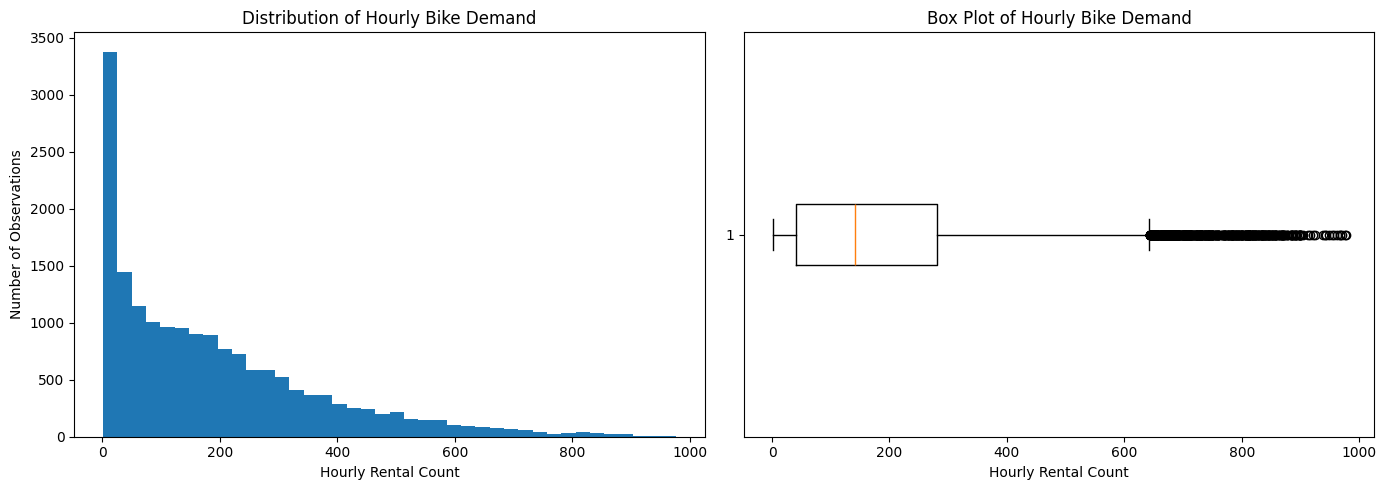

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hour_clean["cnt"], bins=40)
axes[0].set_title("Distribution of Hourly Bike Demand")
axes[0].set_xlabel("Hourly Rental Count")
axes[0].set_ylabel("Number of Observations")

axes[1].boxplot(hour_clean["cnt"], vert=False)
axes[1].set_title("Box Plot of Hourly Bike Demand")
axes[1].set_xlabel("Hourly Rental Count")

plt.tight_layout()
plt.show()

### 6.2 Daily trend

I want to visualie a histroic view of demand from 2011 to 2012. 

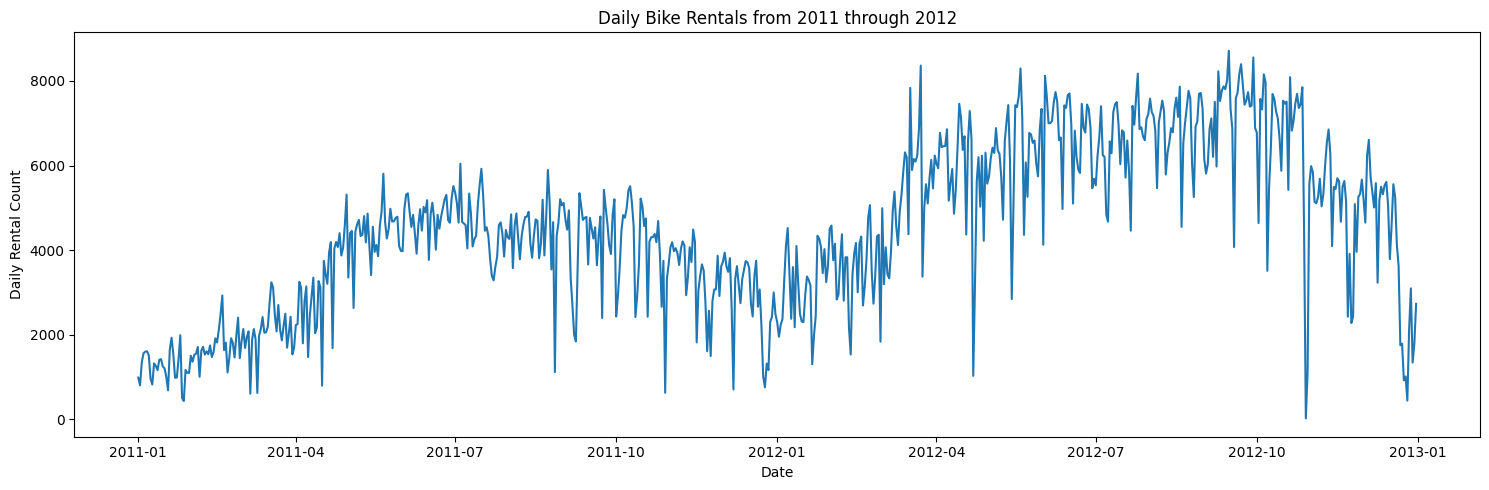

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(day_clean["dteday"], day_clean["cnt"])
plt.title("Daily Bike Rentals from 2011 through 2012")
plt.xlabel("Date")
plt.ylabel("Daily Rental Count")
plt.tight_layout()
plt.show()

### 6.3 Average demand by hour

This is where is becomes more meaningful. We are now going to observe the demand by the hour.  

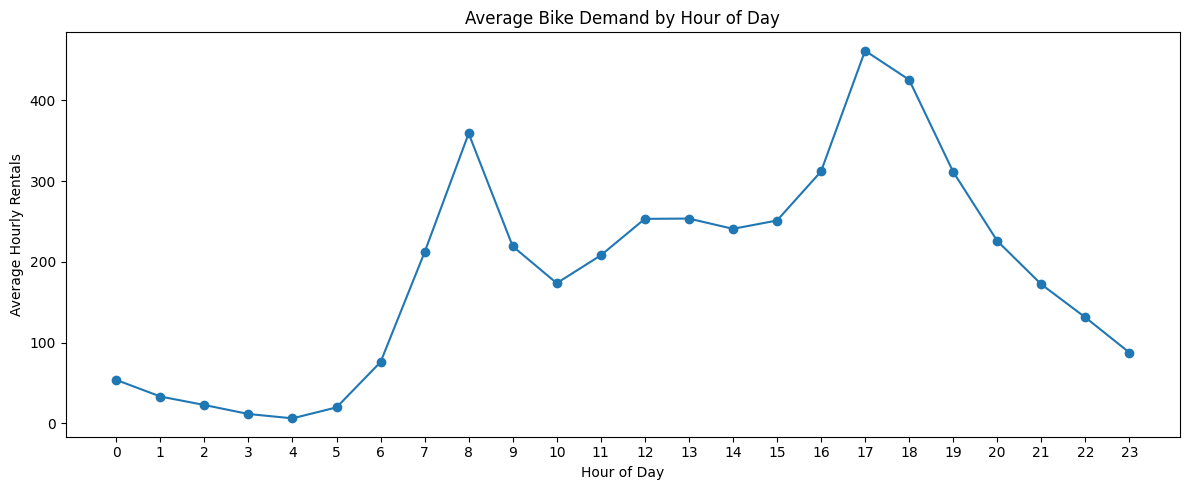

,hr,cnt
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352


In [13]:
hourly_demand = hour_clean.groupby("hr")[["cnt"]].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_demand["hr"], hourly_demand["cnt"], marker="o")
plt.title("Average Bike Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Rentals")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

display(hourly_demand.sort_values("cnt", ascending=False).head())

### 6.4 Working days compared with weekends and holidays

I want to compare working day demand by hour to holiday/weekend demand by hour.  This helps us understand the difference in behavior based on if its a holiday. 

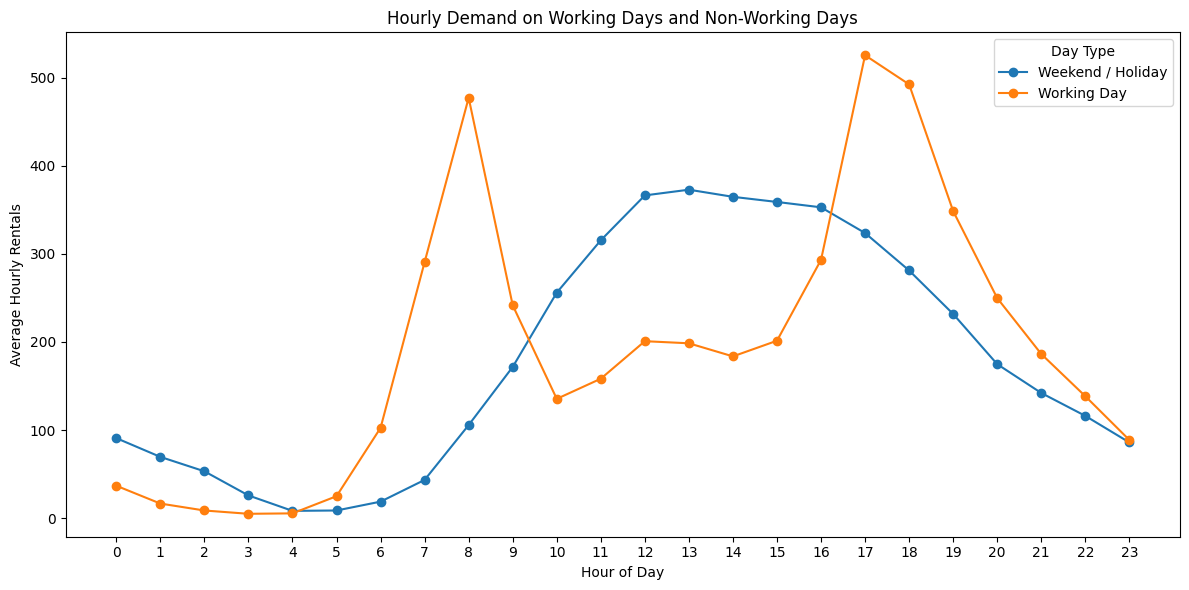

In [14]:
day_type_demand = hour_clean.groupby(["hr", "day_type"])[["cnt"]].mean().reset_index()

plt.figure(figsize=(12, 6))

for day_type in day_type_demand["day_type"].unique():
    day_type_subset = day_type_demand[day_type_demand["day_type"] == day_type]
    plt.plot(day_type_subset["hr"], day_type_subset["cnt"], marker="o", label=day_type)

plt.title("Hourly Demand on Working Days and Non-Working Days")
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Rentals")
plt.xticks(range(0, 24))
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()

### 6.5 Day-of-week and hour heatmap

This is essentially the same thing above except its a heatmap which allows us to visaulize the day of the week as well. 

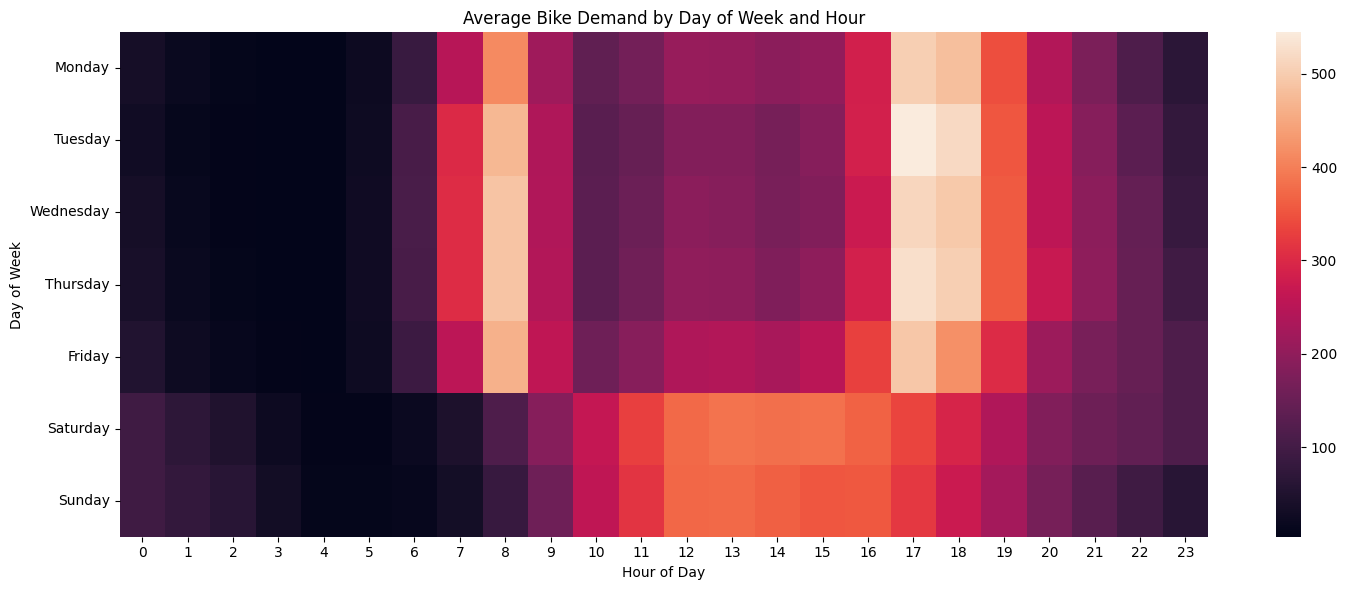

In [15]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_hour = hour_clean.pivot_table(
    index="weekday_name",
    columns="hr",
    values="cnt",
    aggfunc="mean"
).reindex(weekday_order)

plt.figure(figsize=(15, 6))
sns.heatmap(weekday_hour)
plt.title("Average Bike Demand by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

### 6.6 Season and weather

I decided to use box plots because both predictors are categorical and the target is continuous.

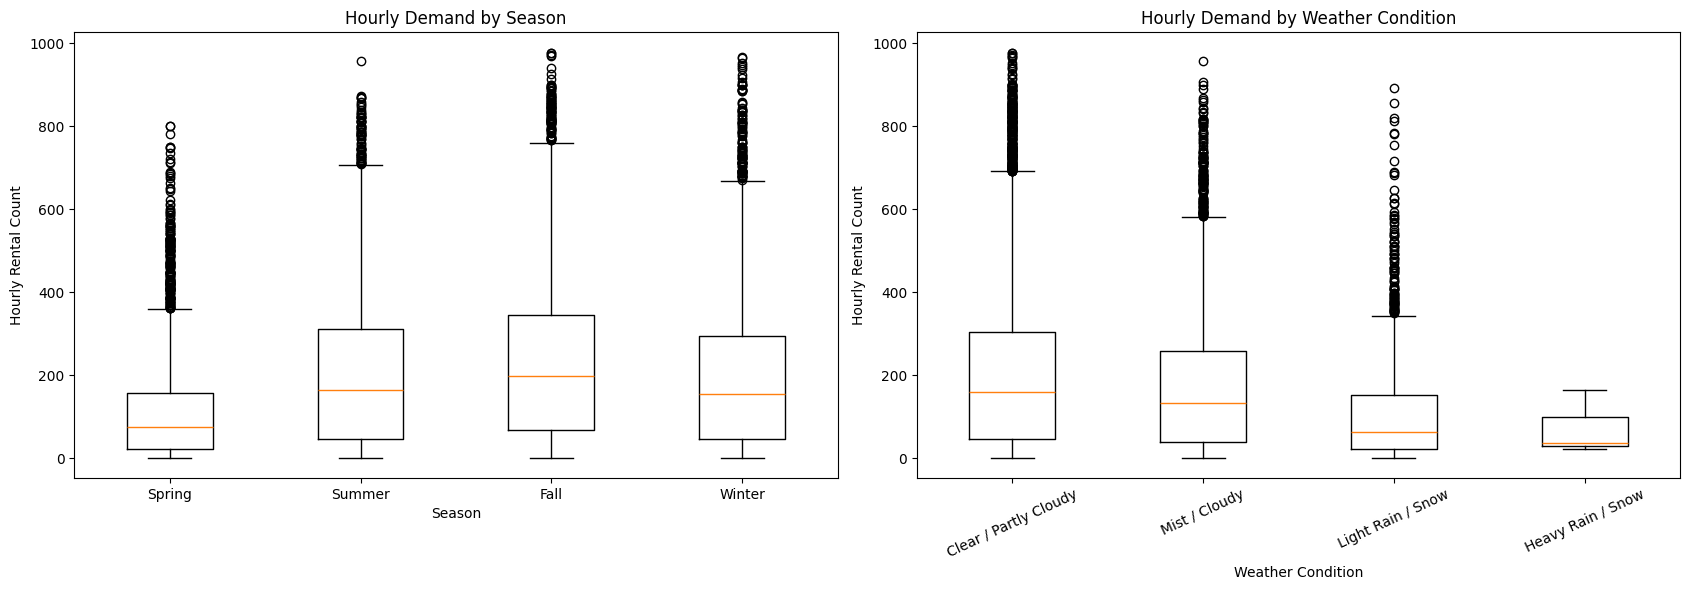

In [16]:
season_order = ["Spring", "Summer", "Fall", "Winter"]
weather_order = [
    "Clear / Partly Cloudy",
    "Mist / Cloudy",
    "Light Rain / Snow",
    "Heavy Rain / Snow"
]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

season_values = [hour_clean.loc[hour_clean["season_name"] == season, "cnt"] for season in season_order]
weather_values = [hour_clean.loc[hour_clean["weather_name"] == weather, "cnt"] for weather in weather_order]

axes[0].boxplot(season_values)
axes[0].set_xticks(range(1, len(season_order) + 1))
axes[0].set_xticklabels(season_order)
axes[0].set_title("Hourly Demand by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Hourly Rental Count")

axes[1].boxplot(weather_values)
axes[1].set_xticks(range(1, len(weather_order) + 1))
axes[1].set_xticklabels(weather_order)
axes[1].set_title("Hourly Demand by Weather Condition")
axes[1].set_xlabel("Weather Condition")
axes[1].set_ylabel("Hourly Rental Count")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [17]:
season_summary = hour_clean.groupby("season_name")[["cnt"]].mean().sort_values("cnt", ascending=False)
weather_summary = hour_clean.groupby("weather_name")["cnt"].agg(["mean", "count"]).sort_values("mean", ascending=False)

display(season_summary)
display(weather_summary)

,cnt
season_name,
Fall,236.016237
Summer,208.344069
Winter,198.868856
Spring,111.114569


,mean,count
weather_name,,
Clear / Partly Cloudy,204.869272,11413
Mist / Cloudy,175.165493,4544
Light Rain / Snow,111.579281,1419
Heavy Rain / Snow,74.333333,3


### 6.7 Year and month

So now I want to focus more on the historic aspect but this time by month and by year. 

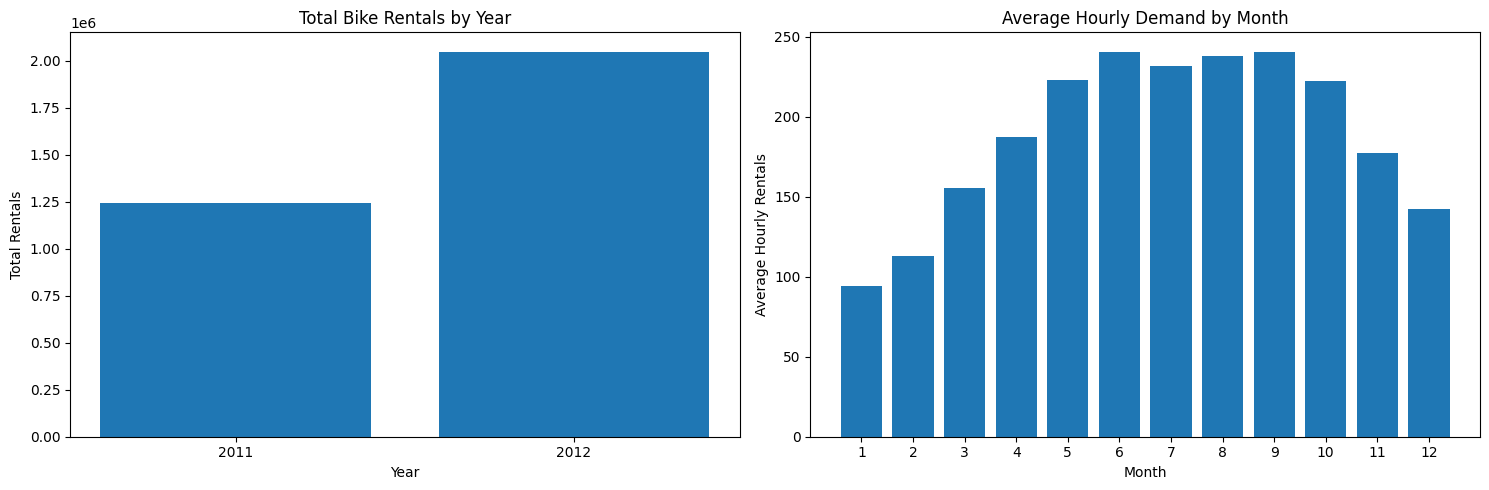

In [18]:
year_summary = day_clean.groupby("year")[["cnt"]].sum().reset_index()
month_summary = hour_clean.groupby("mnth")[["cnt"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(year_summary["year"].astype(str), year_summary["cnt"])
axes[0].set_title("Total Bike Rentals by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Rentals")

axes[1].bar(month_summary["mnth"], month_summary["cnt"])
axes[1].set_title("Average Hourly Demand by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Hourly Rentals")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### 6.8 Continuous environmental variables

So now we are jumping into weather.  I decided to look at scatterplots because they allow us view the continuous relationships between demand and temperature, humidity, and wind speed. 

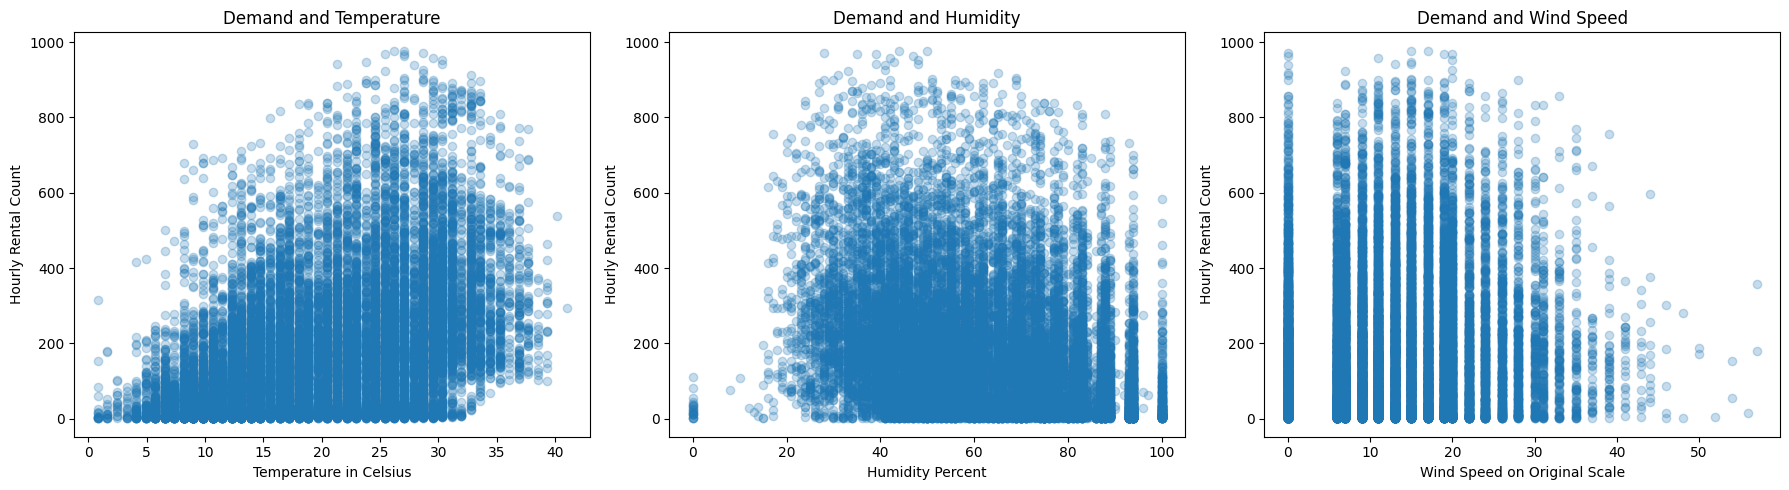

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(hour_clean["temperature_c"], hour_clean["cnt"], alpha=0.25)
axes[0].set_title("Demand and Temperature")
axes[0].set_xlabel("Temperature in Celsius")
axes[0].set_ylabel("Hourly Rental Count")

axes[1].scatter(hour_clean["humidity_percent"], hour_clean["cnt"], alpha=0.25)
axes[1].set_title("Demand and Humidity")
axes[1].set_xlabel("Humidity Percent")
axes[1].set_ylabel("Hourly Rental Count")

axes[2].scatter(hour_clean["windspeed_scale"], hour_clean["cnt"], alpha=0.25)
axes[2].set_title("Demand and Wind Speed")
axes[2].set_xlabel("Wind Speed on Original Scale")
axes[2].set_ylabel("Hourly Rental Count")

plt.tight_layout()
plt.show()

### 6.9 Correlation matrix

We want to go further into this and so I'm utitlizing the matrix because again these are continuous variables. 

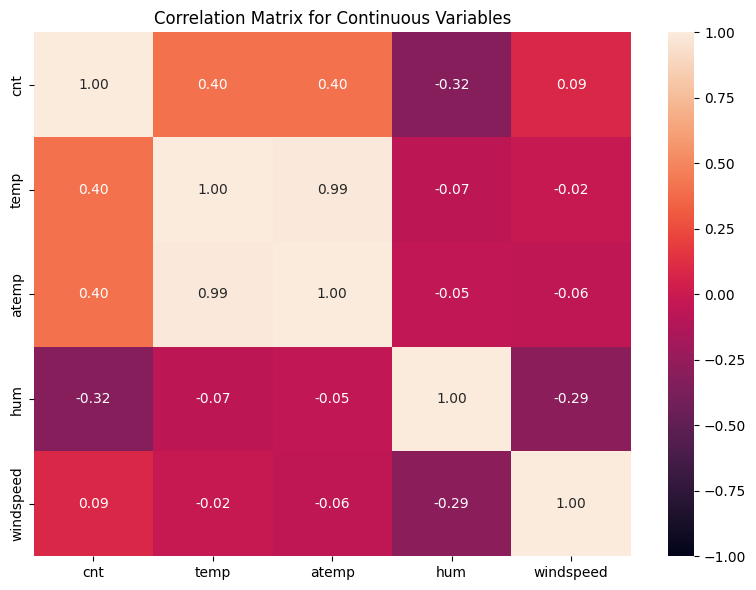

,cnt,temp,atemp,hum,windspeed
cnt,1.000000,0.404772,0.400929,-0.322911,0.093234
temp,0.404772,1.000000,0.987672,-0.069881,-0.023125
atemp,0.400929,0.987672,1.000000,-0.051918,-0.062336
hum,-0.322911,-0.069881,-0.051918,1.000000,-0.290105
windspeed,0.093234,-0.023125,-0.062336,-0.290105,1.000000


In [20]:
correlation_columns = ["cnt", "temp", "atemp", "hum", "windspeed"]
correlations = hour_clean[correlation_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix for Continuous Variables")
plt.tight_layout()
plt.show()

correlations

## 7. Outlier Analysis

I want to spend some time searching for outlietrs. I decided to utilize the IQR method to the hourly target. 

In [21]:
q1 = hour_clean["cnt"].quantile(0.25)
q3 = hour_clean["cnt"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_data = hour_clean[
    (hour_clean["cnt"] < lower_bound) |
    (hour_clean["cnt"] > upper_bound)
]

outlier_summary = pd.Series({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound,
    "outlier_count": len(outlier_data),
    "outlier_percent": len(outlier_data) / len(hour_clean) * 100,
    "maximum_hourly_count": hour_clean["cnt"].max()
})

display(outlier_summary.to_frame("value"))

,value
Q1,40.000000
Q3,281.000000
IQR,241.000000
lower_bound,-321.500000
upper_bound,642.500000
outlier_count,505.000000
outlier_percent,2.905806
maximum_hourly_count,977.000000


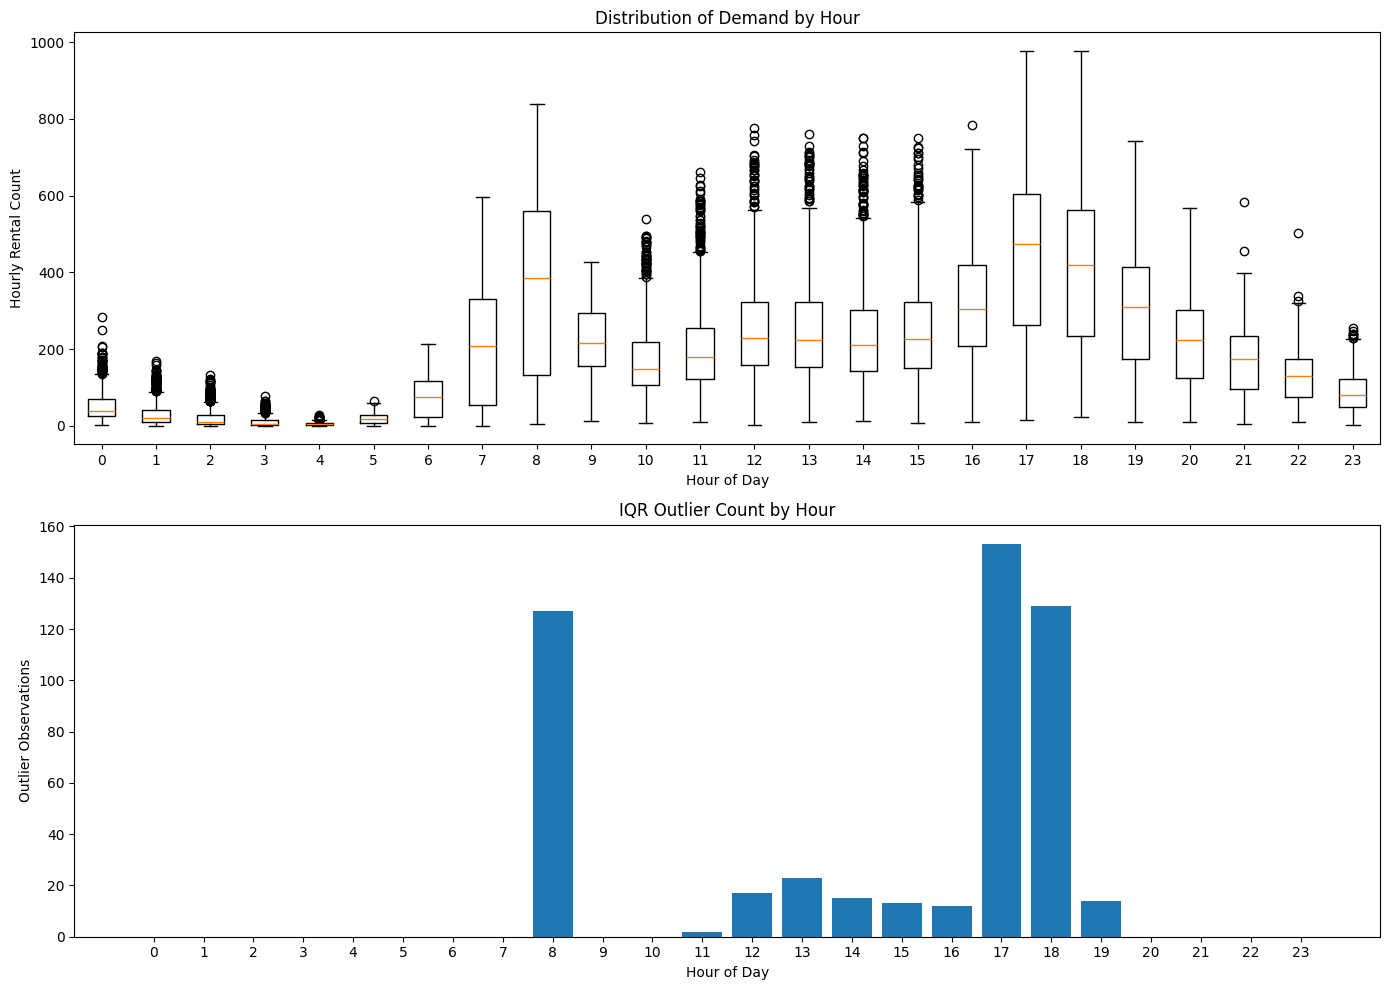

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

hour_values = [hour_clean.loc[hour_clean["hr"] == hour, "cnt"] for hour in range(24)]
outlier_counts = outlier_data["hr"].value_counts().reindex(range(24), fill_value=0)

axes[0].boxplot(hour_values)
axes[0].set_xticks(range(1, 25))
axes[0].set_xticklabels(range(24))
axes[0].set_title("Distribution of Demand by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Hourly Rental Count")

axes[1].bar(outlier_counts.index, outlier_counts.values)
axes[1].set_title("IQR Outlier Count by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Outlier Observations")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

In [23]:
peak_hour_outliers = outlier_data[outlier_data["hr"].isin([8, 17, 18])]
workingday_outliers = outlier_data[outlier_data["workingday"] == 1]

outlier_context = pd.Series({
    "outliers_at_8_17_or_18": len(peak_hour_outliers),
    "percent_at_8_17_or_18": len(peak_hour_outliers) / len(outlier_data) * 100,
    "outliers_on_working_days": len(workingday_outliers),
    "percent_on_working_days": len(workingday_outliers) / len(outlier_data) * 100
})

display(outlier_context.to_frame("value"))

,value
outliers_at_8_17_or_18,409.000000
percent_at_8_17_or_18,80.990099
outliers_on_working_days,414.000000
percent_on_working_days,81.980198


### Outlier decision

According to this we have found 505 outlier_count.  The method used here is the IQR method.  What does this represent? 2.91% of the hourly file. These are found to occur on at 8:00, 17:00, or 18:00, and on working days. 

Should I retain these or remove them? I'm going to keep them because I think they help us identify patterns in other areas.  

## 8. Main EDA Findings

Demand peaks at 17:00 with 461.5 rentals per hour.

Working days show commute peaks with 525.3 rentals at 17:00.

Weekends and holidays have a peak around 13:00.

Rentals had an increase of 64.9% from 2011 to 2012.

Fall has the highest demand in the four seasons. Spring has the lowest.

Clear or partly cloudy weather has a higher demand than light rain or snow.

Temperature has a positive reslationship to demand, and humidity is a negative relationship. 


## 9. Linear Regression Baseline

### 9.1 Modeling design

Because the 'cnt' field is continuous a Linear Regression is best as the initial baseline. The engineered 'hour_workingday field is utlized for the model to represent different patterns by hours for working and non-working days.

The split is 80/20. The first 80% of unique dates is for training, and the remaining is for testing.

In [24]:
categorical_features = [
    "season",
    "mnth",
    "weekday",
    "weathersit",
    "hour_workingday"
]

numeric_features = [
    "yr",
    "holiday",
    "temp",
    "hum",
    "windspeed"
]

X = hour_clean[categorical_features + numeric_features]
y = hour_clean["cnt"]

unique_dates = hour_clean["dteday"].drop_duplicates().sort_values().reset_index(drop=True)
split_date = unique_dates.iloc[int(len(unique_dates) * 0.80)]

train_mask = hour_clean["dteday"] < split_date
test_mask = hour_clean["dteday"] >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

split_summary = pd.Series({
    "split_date": split_date,
    "training_start": hour_clean.loc[train_mask, "dteday"].min(),
    "training_end": hour_clean.loc[train_mask, "dteday"].max(),
    "testing_start": hour_clean.loc[test_mask, "dteday"].min(),
    "testing_end": hour_clean.loc[test_mask, "dteday"].max(),
    "training_rows": len(X_train),
    "testing_rows": len(X_test)
})

display(split_summary.to_frame("value"))

,value
split_date,2012-08-07 00:00:00
training_start,2011-01-01 00:00:00
training_end,2012-08-06 00:00:00
testing_start,2012-08-07 00:00:00
testing_end,2012-12-31 00:00:00
training_rows,13891
testing_rows,3488


### 9.2 Fit the baseline model

We are applying a pipleine to process the model using scikit-learn pipeline.

In [25]:
transformer = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    remainder="passthrough"
)

baseline_model = Pipeline([
    ("transformer", transformer),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

train_predictions = baseline_model.predict(X_train)
test_predictions = baseline_model.predict(X_test)

### 9.3 Evaluation metrics

I am goign to use MAE as the primary metric because it reports prediction error in rentals per hour. MSE and RMSE give us more or larger errors.

In [26]:
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

model_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Training": [
        mean_absolute_error(y_train, train_predictions),
        train_mse,
        np.sqrt(train_mse),
        baseline_model.score(X_train, y_train)
    ],
    "Testing": [
        mean_absolute_error(y_test, test_predictions),
        test_mse,
        np.sqrt(test_mse),
        baseline_model.score(X_test, y_test)
    ]
})

display(model_results.round(3))

,Metric,Training,Testing
0,MAE,51.303,78.225
1,MSE,4992.989,11026.488
2,RMSE,70.661,105.007
3,R-squared,0.821,0.773


### Baseline interpretation

The chronological test results are as follows:

- **MAE: 78.23 rentals per hour**
- **MSE: 11,026.49**
- **RMSE: 105.01 rentals per hour**
- **R-squared: 0.773**



### 9.4 Actual and predicted demand

Shown below is a two-week section of the test period:

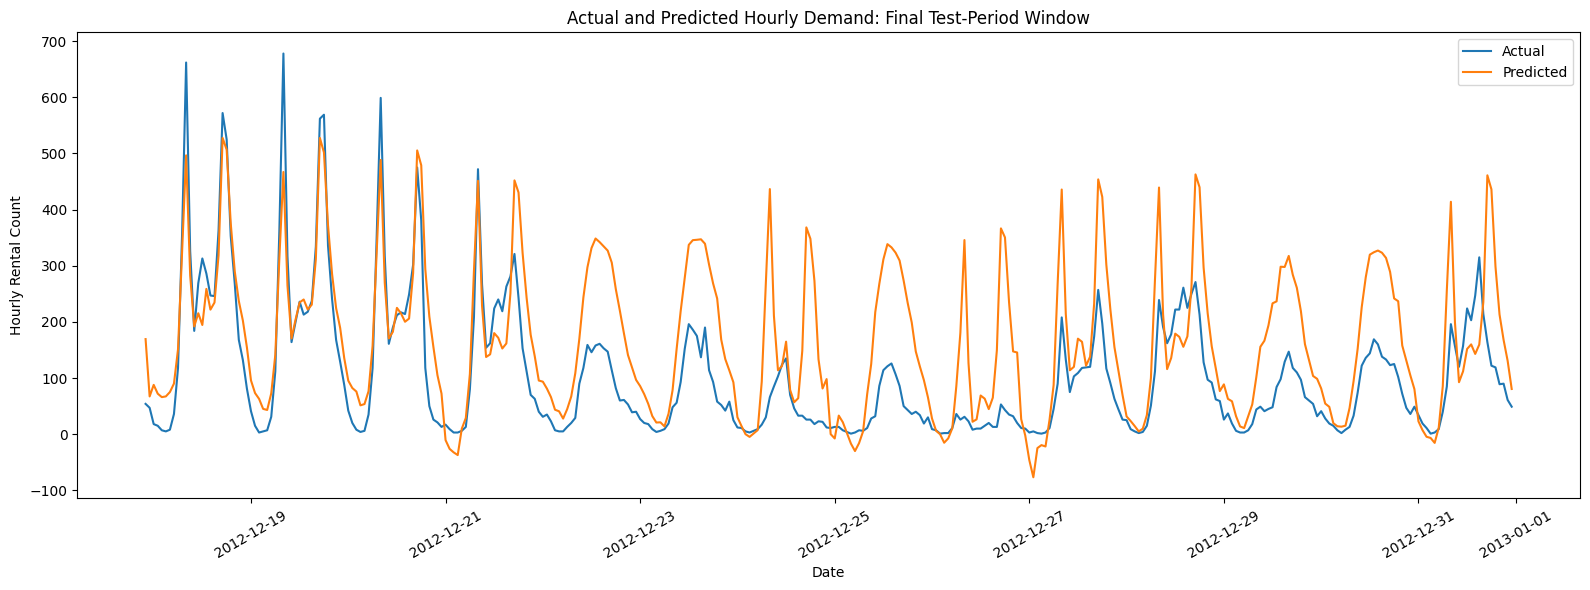

In [27]:
prediction_results = pd.DataFrame({
    "datetime": hour_clean.loc[test_mask, "datetime"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": test_predictions
})

plot_window = prediction_results.tail(24 * 14)

plt.figure(figsize=(16, 6))
plt.plot(plot_window["datetime"], plot_window["actual"], label="Actual")
plt.plot(plot_window["datetime"], plot_window["predicted"], label="Predicted")
plt.title("Actual and Predicted Hourly Demand: Final Test-Period Window")
plt.xlabel("Date")
plt.ylabel("Hourly Rental Count")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 9.5 Residual analysis

Residuals are determined by taking the actual and subtracting the predicted. So the positive residuals show under-prediction, white the negative residuals show over-prediction.

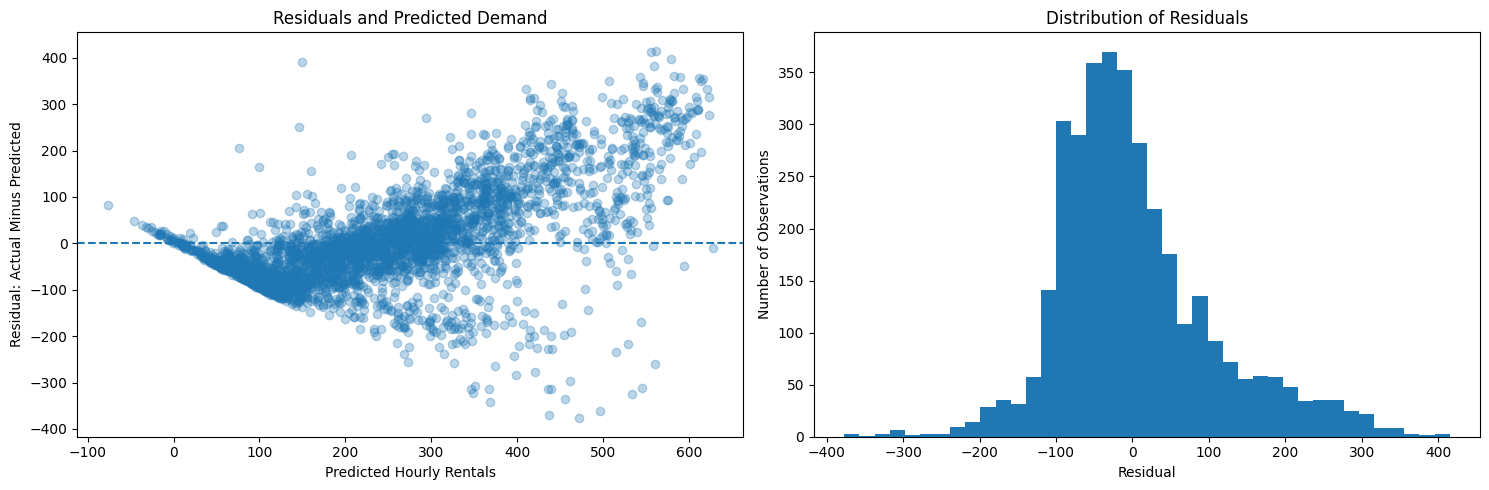

In [28]:
prediction_results["residual"] = prediction_results["actual"] - prediction_results["predicted"]
prediction_results["absolute_error"] = prediction_results["residual"].abs()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(prediction_results["predicted"], prediction_results["residual"], alpha=0.30)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals and Predicted Demand")
axes[0].set_xlabel("Predicted Hourly Rentals")
axes[0].set_ylabel("Residual: Actual Minus Predicted")

axes[1].hist(prediction_results["residual"], bins=40)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

In [29]:
high_demand_results = prediction_results[prediction_results["actual"] > 600]

error_summary = pd.Series({
    "negative_predictions": (prediction_results["predicted"] < 0).sum(),
    "high_demand_observations": len(high_demand_results),
    "mean_high_demand_residual": high_demand_results["residual"].mean(),
    "high_demand_mae": high_demand_results["absolute_error"].mean()
})

display(error_summary.to_frame("value"))

,value
negative_predictions,28.000000
high_demand_observations,310.000000
mean_high_demand_residual,226.940324
high_demand_mae,227.008745


## 10. Baseline Conclusions

The Linear Regression model predicts hourly demand quite well. We are seeing an MAE of 78 rentals and an R squared of of 0.773. Time of day and the working day is also noticable. We also see that the season, weather, temperature, and humidity are also helpful. However, the model creates was wrong 28 times with negative predictions.  We also see it underpredicted demand: above 600 rentals by about 227. 

## 11. Additional Modeling

The Linear Regression baseline will now be compared with Ridge and LASSO Regression. StandardScaler, chronological cross-validation, and GridSearchCV will be used to select and compare the final models.

## 12. Final Model Comparison

The Linear Regression baseline is compared with Ridge and LASSO Regression. Three chronological cross-validation folds keep earlier dates in training and validation for later dates. GridSearchCV selects the best alpha for Ridge and LASSO.

MAE remains the main test metric because it reports the average error in rentals per hour. RMSE and R-squared are also included.

In [31]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

training_dates = hour_clean.loc[train_mask, "dteday"].reset_index(drop=True)
cv_dates = training_dates.drop_duplicates().sort_values().reset_index(drop=True)

cv_cut_1 = cv_dates.iloc[int(len(cv_dates) * 0.50)]
cv_cut_2 = cv_dates.iloc[int(len(cv_dates) * 0.65)]
cv_cut_3 = cv_dates.iloc[int(len(cv_dates) * 0.80)]

chronological_cv = [
    (
        np.where(training_dates < cv_cut_1)[0],
        np.where(
            (training_dates >= cv_cut_1) &
            (training_dates < cv_cut_2)
        )[0]
    ),
    (
        np.where(training_dates < cv_cut_2)[0],
        np.where(
            (training_dates >= cv_cut_2) &
            (training_dates < cv_cut_3)
        )[0]
    ),
    (
        np.where(training_dates < cv_cut_3)[0],
        np.where(training_dates >= cv_cut_3)[0]
    )
]

regularized_transformer = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (StandardScaler(), numeric_features)
)

ridge_pipeline = Pipeline([
    ("transformer", regularized_transformer),
    ("model", Ridge())
])

lasso_pipeline = Pipeline([
    ("transformer", regularized_transformer),
    ("model", Lasso(max_iter=10000))
])

alpha_values = 10**np.linspace(-3, 3, 7)

linear_grid = GridSearchCV(
    estimator=baseline_model,
    param_grid={},
    scoring="neg_mean_squared_error",
    cv=chronological_cv
)

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"model__alpha": alpha_values},
    scoring="neg_mean_squared_error",
    cv=chronological_cv
)

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={"model__alpha": alpha_values},
    scoring="neg_mean_squared_error",
    cv=chronological_cv
)

linear_grid.fit(X_train, y_train)
ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

linear_final_predictions = linear_grid.predict(X_test)
ridge_final_predictions = ridge_grid.predict(X_test)
lasso_final_predictions = lasso_grid.predict(X_test)

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "LASSO Regression"
    ],
    "Best Alpha": [
        "Not applicable",
        ridge_grid.best_params_["model__alpha"],
        lasso_grid.best_params_["model__alpha"]
    ],
    "CV RMSE": [
        np.sqrt(-linear_grid.best_score_),
        np.sqrt(-ridge_grid.best_score_),
        np.sqrt(-lasso_grid.best_score_)
    ],
    "Test MAE": [
        mean_absolute_error(y_test, linear_final_predictions),
        mean_absolute_error(y_test, ridge_final_predictions),
        mean_absolute_error(y_test, lasso_final_predictions)
    ],
    "Test MSE": [
        mean_squared_error(y_test, linear_final_predictions),
        mean_squared_error(y_test, ridge_final_predictions),
        mean_squared_error(y_test, lasso_final_predictions)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_final_predictions)),
        np.sqrt(mean_squared_error(y_test, ridge_final_predictions)),
        np.sqrt(mean_squared_error(y_test, lasso_final_predictions))
    ],
    "Test R-squared": [
        linear_grid.best_estimator_.score(X_test, y_test),
        ridge_grid.best_estimator_.score(X_test, y_test),
        lasso_grid.best_estimator_.score(X_test, y_test)
    ]
})

model_comparison = (
    model_comparison
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

display(model_comparison.round(3))

,Model,Best Alpha,CV RMSE,Test MAE,Test MSE,Test RMSE,Test R-squared
0,Linear Regression,Not applicable,86.977,78.225,11026.488,105.007,0.773
1,Ridge Regression,0.001,86.980,78.222,11026.287,105.006,0.773
2,LASSO Regression,0.001,87.105,78.242,11029.702,105.022,0.773


## 13. Final Modeling Findings

All three models performed pretty much the same. Linear Regression had the lowest cross-validation RMSE at about 86.98. Ridge had a lower test MAE, but the difference was less than one rental and so it is not meaningful.

Ridge and LASSO both selected an alpha of 0.001, which means only a small amount of regularization was needed. All three models had a test R-squared of 0.773.

Linear Regression is preferred because it is the simplest method and regularization did not impact anything really. The model predicts hourly demand pretty well.

Bike availability should be prioritized during the working-day peaks around 8:00, 17:00, and 18:00. Future work should focus on improving predictions during these peak-demand hours.